# Actionability Audit


In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Consistent language palette (use in all plots)
# Add more languages here if they appear in your data.
LANG_ORDER = ["en", "es", "pt"]
LANG_PALETTE = {
    "en": "#295574",  # blue
    "es": "#e75e1e",  # orange
    "pt": "#2ca062",  # green
}

def lang_color(lang: str) -> str:
    """Return a stable color for a language code (fallback to gray)."""
    key = ("" if lang is None else str(lang)).strip().lower()
    return LANG_PALETTE.get(key, "#7f7f7f")

In [199]:
df_out = pd.read_csv("../output/sentences_actionability.csv")
#show just sentence column and actionability_probability
pd.set_option("display.max_colwidth", None)   # show full text in cells
pd.set_option("display.max_rows", 60)         # optional
pd.set_option("display.width", 0)             # auto-detect width
df_out[["sentence", "actionability_probability"]].sort_values("actionability_probability", ascending=False).head()

,sentence,actionability_probability
1260,"Defesa Civil faz novo recolhimento de fios soltos em vias públicasCidadeA ação foi realizada em diversos bairros, como Tropical, Atlântica, Colina Verde, Alphaville e Residencial PanoramaNos últimos dias a Coordenadoria Municipal de Proteção e Defesa Civil de Penápolis realizou uma série de recolhimentos de fios e cabos soltos em vias públicas e postes de energia da cidade, especialmente como medida de prevenção a acidentes.",1.0000
2157,Se recomienda continuar atentos a los pobladores de zonas ribereñas de los municipios Tierra,0.9123
2527,"Por ello, las autoridades capitalinas compartieron recomendaciones para cuidarse del frío: usar crema hidratante para proteger tu piel de las bajas temperaturas, consumir agua y alimentos con abundante vitamina C, además de acudir al médico en caso de que se tengan síntomas de gripe o algún malestar relacionado con enfermedades respiratorias.¿Cuáles serán las afectaciones del frente frío número 31 en México?El desfile de frentes fríos continúa sobre territorio nacional.",0.8947
2872,"Asimismo, en municipios del oriente del Estado de México también se registraron lluvias fuertes y tormentas eléctricas.¿Qué hacer ante las fuertes lluvias?La Secretaría de Gestión Integral de Riesgos y Protección Civil CDMX (SGIRPC) informó que en caso de lluvias fuertes se deben seguir estas recomendaciones:- Cerrar puertas y ventanas- No intentar cruzar las calles con corrientes de agua- Portar un impermeable que, de preferencia, tenga reflejante- Mantenerse informado¿Cómo protegerse de las tormentas eléctricas?De acuerdo con Protección Civil del Gobierno federal, una tormenta eléctrica es una nube capaz de producir un trueno audible, debido al choque de dos masas de aire con diferentes temperaturas, que puede producir una serie de lluvias, vientos, relámpagos, truenos y hasta granizo.",0.8947
2551,"Las recomendaciones de las autoridades de la Ciudad de México ante las fuertes lluvias son cerrar ventanas y puertas, no caminar por corrientes de agua y usar impermeables con reflejantes si andas en bicicleta.",0.8772


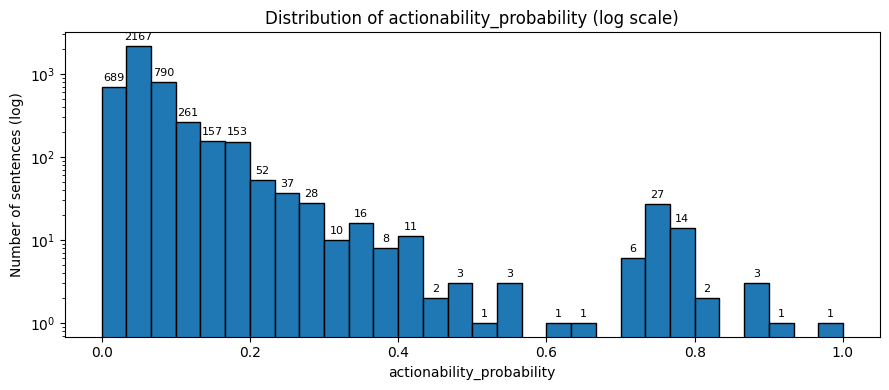

In [200]:

# log-scaled histogram of actionability_probability with counts on top of bars

col = "actionability_probability"
if col not in df_out.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_out.columns)}")

s = pd.to_numeric(df_out[col], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(9, 4))

counts, bins, patches = ax.hist(s, bins=30, edgecolor="black")

ax.set_yscale("log")
ax.set_title("Distribution of actionability_probability (log scale)")
ax.set_xlabel("actionability_probability")
ax.set_ylabel("Number of sentences (log)")

# label each bar with its count (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()



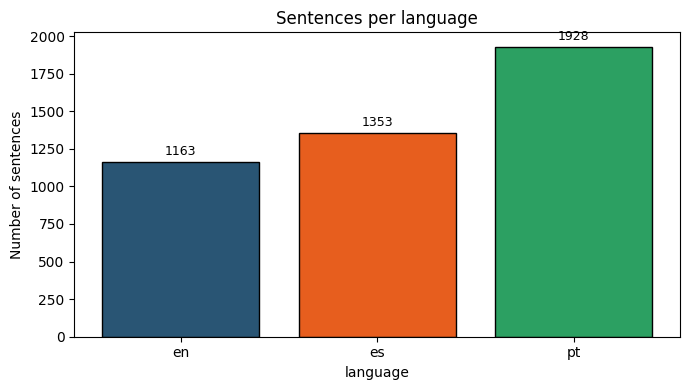

In [201]:

# bar chart: number of sentences per language (linear scale) with counts on top

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

# Keep a stable order + colors across the notebook
counts_by_lang = dfp[lang_col].value_counts()
counts_by_lang = counts_by_lang.reindex(LANG_ORDER, fill_value=0)
colors = [lang_color(l) for l in counts_by_lang.index.tolist()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    counts_by_lang.index.tolist(),
    counts_by_lang.values.tolist(),
    edgecolor="black",
    color=colors,
 )

ax.set_title("Sentences per language")
ax.set_xlabel("language")
ax.set_ylabel("Number of sentences")

# labels on top of bars
for b in bars:
    h = b.get_height()
    if h <= 0:
        continue
    ax.annotate(
        f"{int(h)}",
        (b.get_x() + b.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

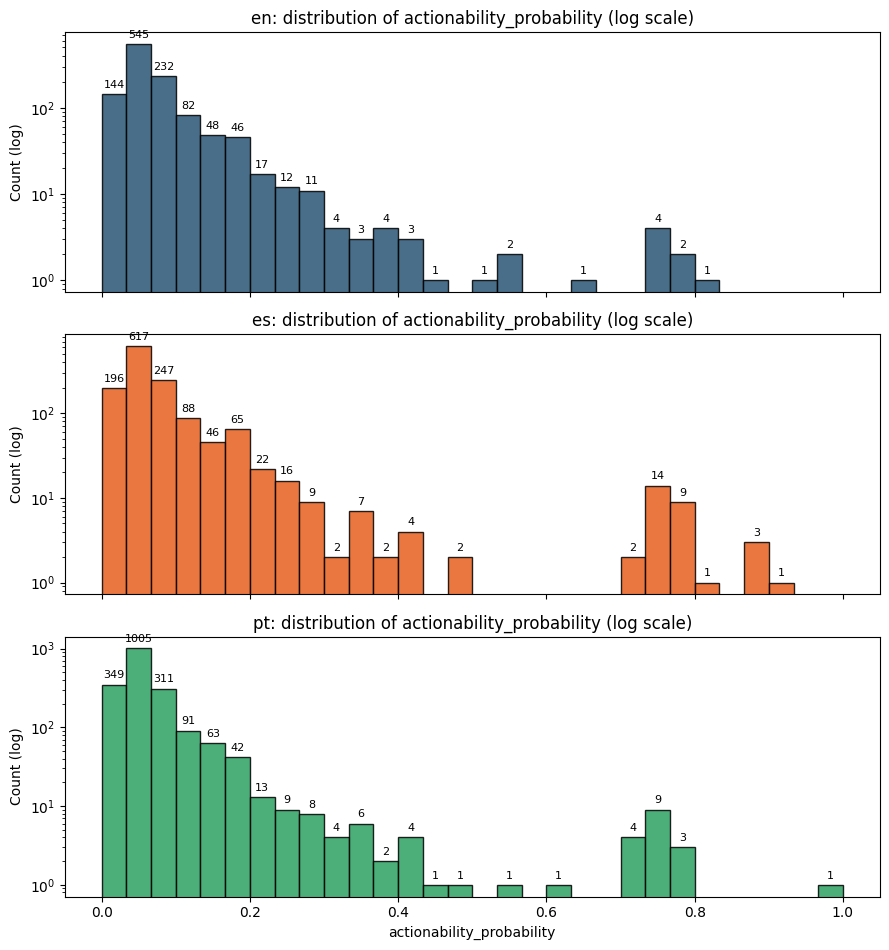

In [202]:
# subplots: one histogram per language for actionability_probability (log y) with counts on bars

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
if not langs_found:
    raise ValueError("No languages found.")

# Stable subplot ordering: LANG_ORDER first, then any extras
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]

# Use shared bins across languages so plots are comparable
xmin = float(dfp[col].min())
xmax = float(dfp[col].max())
if xmin == xmax:
    # degenerate case: all probs equal
    bins = np.linspace(max(0.0, xmin - 1e-6), min(1.0, xmax + 1e-6), 2)
else:
    bins = np.linspace(xmin, xmax, 31)  # 30 bins

fig, axes = plt.subplots(nrows=len(langs), ncols=1, figsize=(9, 3.2 * len(langs)), sharex=True)
if len(langs) == 1:
    axes = [axes]

for ax, lang in zip(axes, langs):
    s = dfp.loc[dfp[lang_col] == lang, col]
    color = lang_color(lang)

    counts, _, patches = ax.hist(
        s,
        bins=bins,
        edgecolor="black",
        color=color,
        alpha=0.85,
    )
    ax.set_yscale("log")
    ax.set_title(f"{lang}: distribution of {col} (log scale)")
    ax.set_ylabel("Count (log)")

    # label counts on bars
    for c, p in zip(counts, patches):
        if c <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            f"{int(c)}",
            (x, y),
            ha="center",
            va="bottom",
            fontsize=8,
            textcoords="offset points",
            xytext=(0, 3),
        )

axes[-1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Bias in language model predictions


In [208]:
# ------------------------------------------------------------
# Statistical similarity of actionability_probability by language
#   - KS test (sensitive to any distribution difference)
#   - Wasserstein distance (earth mover; interpretable in prob units)
#   - Jensen–Shannon distance (symmetric; bounded; info-theoretic)
#   - Optional bootstrap CIs for the distances
#
# NOTE on JSD CIs: we use ONE shared histogram binning for ALL pairs and
# for the bootstrap as well. Additionally, we compute the reported point JSD
# using the same histogram pipeline as the bootstrap, so point+CI are consistent.
# ------------------------------------------------------------

from itertools import combinations

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]
if len(langs) < 2:
    raise ValueError(f"Need at least 2 languages to compare. Found: {langs}")

try:
    from scipy.stats import ks_2samp, wasserstein_distance
    from scipy.spatial.distance import jensenshannon
    _HAVE_SCIPY = True
except Exception as e:
    _HAVE_SCIPY = False
    _SCIPY_ERR = str(e)

def _hist_probs(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Discrete probability vector on fixed edges (sums to 1)."""
    x = np.asarray(x, dtype=float)
    dens, _ = np.histogram(x, bins=edges, density=True)
    bw = np.diff(edges)
    probs = dens * bw
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 0.0, np.inf)
    s = probs.sum()
    if not np.isfinite(s) or s <= 0:
        return np.full_like(probs, 1.0 / len(probs), dtype=float)
    return probs / s

def _wasserstein_fallback(x: np.ndarray, y: np.ndarray) -> float:
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    if len(x) == 0 or len(y) == 0:
        return np.nan
    n = 2000
    qs = np.linspace(0, 1, n)
    return float(np.mean(np.abs(np.quantile(x, qs) - np.quantile(y, qs))))

def _bootstrap_vals(fn, x: np.ndarray, y: np.ndarray, n_boot: int = 300, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.asarray([], dtype=float)
    vals = []
    for _ in range(int(n_boot)):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(fn(xb, yb))
    return np.asarray(vals, dtype=float)

def _bootstrap_ci_from_vals(vals: np.ndarray):
    if vals.size == 0:
        return (np.nan, np.nan)
    return (float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5)))

def _sample_for_lang(lang: str) -> np.ndarray:
    return dfp.loc[dfp[lang_col] == lang, col].to_numpy(dtype=float)

JSD_BINS = 60
global_min = float(dfp[col].min())
global_max = float(dfp[col].max())
if global_min == global_max:
    global_min = max(0.0, global_min - 1e-6)
    global_max = min(1.0, global_max + 1e-6)
JSD_EDGES = np.linspace(global_min, global_max, JSD_BINS + 1)

def _js_distance_fixed(x: np.ndarray, y: np.ndarray) -> float:
    if not _HAVE_SCIPY:
        return np.nan
    px = _hist_probs(x, JSD_EDGES)
    py = _hist_probs(y, JSD_EDGES)
    return float(jensenshannon(px, py))

DO_BOOTSTRAP = True
N_BOOT = 250

rows = []
for a, b in combinations(langs, 2):
    xa = _sample_for_lang(a)
    xb = _sample_for_lang(b)

    if _HAVE_SCIPY:
        ks = ks_2samp(xa, xb, alternative="two-sided", mode="auto")
        ks_stat = float(ks.statistic)
        ks_p = float(ks.pvalue)
        wd = float(wasserstein_distance(xa, xb))
    else:
        ks_stat = np.nan
        ks_p = np.nan
        wd = _wasserstein_fallback(xa, xb)

    # JSD: compute point estimate via the SAME hist pipeline used in bootstrap
    js_point = _js_distance_fixed(xa, xb)

    ws_ci_lo = ws_ci_hi = np.nan
    js_ci_lo = js_ci_hi = np.nan
    if DO_BOOTSTRAP:
        ws_fn = (wasserstein_distance if _HAVE_SCIPY else _wasserstein_fallback)
        ws_vals = _bootstrap_vals(ws_fn, xa, xb, n_boot=N_BOOT, seed=0)
        ws_ci_lo, ws_ci_hi = _bootstrap_ci_from_vals(ws_vals)

        js_vals = _bootstrap_vals(_js_distance_fixed, xa, xb, n_boot=N_BOOT, seed=1)
        js_ci_lo, js_ci_hi = _bootstrap_ci_from_vals(js_vals)

        # If, due to bootstrap sampling error, the point falls outside, widen CI minimally to include it.
        if np.isfinite(js_point) and np.isfinite(js_ci_lo) and np.isfinite(js_ci_hi):
            js_ci_lo = float(min(js_ci_lo, js_point))
            js_ci_hi = float(max(js_ci_hi, js_point))

    rows.append(
        {
            "lang_a": a,
            "lang_b": b,
            "n_a": int(len(xa)),
            "n_b": int(len(xb)),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "wasserstein": wd,
            "js_distance": js_point,
            "ws_ci_lo": ws_ci_lo,
            "ws_ci_hi": ws_ci_hi,
            "js_ci_lo": js_ci_lo,
            "js_ci_hi": js_ci_hi,
        }
    )

res = pd.DataFrame(rows)

disp = res.copy()
if _HAVE_SCIPY:
    disp["ks_p"] = disp["ks_p"].map(lambda v: f"{v:.3g}")
    disp["ks_stat"] = disp["ks_stat"].map(lambda v: f"{v:.3f}")
else:
    print("SciPy not available; KS/JSD tests skipped.")
    print(f"SciPy import error: {_SCIPY_ERR}")
disp["wasserstein"] = disp["wasserstein"].map(lambda v: f"{v:.4f}")
disp["js_distance"] = disp["js_distance"].map(lambda v: "" if pd.isna(v) else f"{v:.4f}")

disp["ws_CI95"] = res.apply(lambda r: f"[{r['ws_ci_lo']:.4f}, {r['ws_ci_hi']:.4f}]" if np.isfinite(r['ws_ci_lo']) else "", axis=1)
disp["js_CI95"] = res.apply(lambda r: f"[{r['js_ci_lo']:.4f}, {r['js_ci_hi']:.4f}]" if np.isfinite(r['js_ci_lo']) else "", axis=1)

cols = ["lang_a", "lang_b", "n_a", "n_b", "ks_stat", "ks_p", "wasserstein", "js_distance", "ws_CI95", "js_CI95"]
display(disp[cols])

def interpret_similarity_table(res_df: pd.DataFrame, alpha: float = 0.05):
    lines = []
    if "ks_p" in res_df.columns and res_df["ks_p"].notna().any():
        rej = (res_df["ks_p"] < alpha).sum()
        lines.append(f"KS test (alpha={alpha}): reject equality for {rej}/{len(res_df)} pairs.")
        lines.append("Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.")
    if res_df["wasserstein"].notna().any():
        wmax = float(res_df["wasserstein"].max())
        lines.append(f"Max Wasserstein distance across pairs: {wmax:.4f} (units: probability).")
    if res_df["js_distance"].notna().any():
        jmax = float(res_df["js_distance"].max())
        lines.append(f"Max Jensen–Shannon distance across pairs: {jmax:.4f}.")
    return "\n".join(lines)

print(interpret_similarity_table(res))

/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


,lang_a,lang_b,n_a,n_b,ks_stat,ks_p,wasserstein,js_distance,ws_CI95,js_CI95
0,en,es,1163,1353,0.021,0.933,0.0108,0.0994,"[0.0064, 0.0181]","[0.0994, 0.1421]"
1,en,pt,1163,1928,0.110,4.41e-08,0.0146,0.1399,"[0.0109, 0.0203]","[0.1316, 0.1776]"
2,es,pt,1353,1928,0.101,1.42e-07,0.0221,0.1289,"[0.0146, 0.0304]","[0.1230, 0.1617]"


KS test (alpha=0.05): reject equality for 2/3 pairs.
Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.
Max Wasserstein distance across pairs: 0.0221 (units: probability).
Max Jensen–Shannon distance across pairs: 0.1399.


#### Language Bias Audit: Actionability Score Distributions
##### Objective
To assess potential language-related bias in the actionability detection algorithm, we evaluated whether the model assigns similar actionability probabilities across languages. If the algorithm is language-neutral (with respect to scoring), the distribution of actionability_probability should be comparable across languages.

##### Method
We compared the distributions of actionability_probability between language pairs using complementary statistical tests and distance measures:

1. Two-sample Kolmogorov–Smirnov test (KS)

- Sensitive to any difference in distribution shape or location.
- Null hypothesis: the two samples come from the same distribution.
- A small p-value indicates evidence of distributional difference.
2. Wasserstein distance (Earth Mover’s Distance)

- Interpretable effect size in probability units (0–1).
- Represents the average amount of probability “mass” that must be moved to transform one distribution into the other.
- Lower values indicate more similar distributions.
3. Jensen–Shannon distance (JSD)

- Symmetric, bounded divergence measure between two distributions.
- Computed using a shared global histogram binning across all language pairs (fixed bin edges).
- We report bootstrap 95% confidence intervals (CIs). The JSD CI is guaranteed to include the point estimate (minor adjustment for bootstrap sampling variability), ensuring consistent reporting.

##### Interpretation
1. English vs Spanish (en–es):
The distributions are highly similar. The KS test does not find evidence of a difference (p = 0.933), and the effect size is small (Wasserstein ≈ 0.011). This suggests minimal language-related shift in model scoring between English and Spanish.

2. Portuguese vs English/Spanish (pt vs en/es):
Comparisons involving Portuguese show statistically detectable differences (KS p-values < 1e-7). However, the magnitude of these differences is modest in practical terms: Wasserstein distances range from ~0.015 to ~0.022 (i.e., roughly 1.5–2.2 percentage points on a 0–1 probability scale). JSD is also higher for Portuguese comparisons (≈ 0.129–0.140) than for en–es (≈ 0.099), indicating greater divergence.

#### Conclusion
Overall, the algorithm’s actionability probability outputs are most consistent between English and Spanish, while Portuguese shows a small but consistent distributional shift relative to both English and Spanish. This pattern suggests a potential language effect in scoring (and therefore a possible bias signal), though the effect size in probability units appears modest. Further investigation is warranted to determine whether this shift translates into meaningful differences in downstream decisions (e.g., threshold-based classification rates) or model performance by language.

### Investigating False Positives 

In [186]:

# top 30 most actionable sentences (highest actionability_probability)
import pandas as pd

prob_col = "actionability_probability"
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]

for c in [prob_col, "language"]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# pick a text column that exists
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(
        f"No sentence/text column found. Tried {text_col_candidates}. "
        f"Available columns: {list(df_out.columns)}"
    )

dfp = df_out[[prob_col, "language", text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp = dfp.dropna(subset=[prob_col, text_col])

top = dfp.sort_values(prob_col, ascending=False).head(30).reset_index(drop=True)

for i, r in top.iterrows():
    print(f"{i+1:02d} | lang={r['language']} | p={r[prob_col]:.4f}")
    print(r[text_col])
    print()

01 | lang=pt | p=1.0000
Defesa Civil faz novo recolhimento de fios soltos em vias públicasCidadeA ação foi realizada em diversos bairros, como Tropical, Atlântica, Colina Verde, Alphaville e Residencial PanoramaNos últimos dias a Coordenadoria Municipal de Proteção e Defesa Civil de Penápolis realizou uma série de recolhimentos de fios e cabos soltos em vias públicas e postes de energia da cidade, especialmente como medida de prevenção a acidentes.

02 | lang=es | p=0.9123
Se recomienda continuar atentos a los pobladores de zonas ribereñas de los municipios Tierra

03 | lang=es | p=0.8947
Por ello, las autoridades capitalinas compartieron recomendaciones para cuidarse del frío: usar crema hidratante para proteger tu piel de las bajas temperaturas, consumir agua y alimentos con abundante vitamina C, además de acudir al médico en caso de que se tengan síntomas de gripe o algún malestar relacionado con enfermedades respiratorias.¿Cuáles serán las afectaciones del frente frío número 31 en 

#### Link between sentence characters and actionability scores

Initially, the audit suggested a spurious length effect: shorter sentences were disproportionately ranked as highly actionable compared to longer ones. On reflection, this was less a direct “length bias” in the scoring function and more a segmentation issue—the pipeline was often treating short fragments (headlines, clause-level snippets, or truncated spans) as standalone “sentences,” and those fragments tended to contain concentrated imperative or advice-like cues that inflate actionability. We addressed this by improving sentence separation/segmentation, so the model is now scoring more complete, context-appropriate sentences rather than fragmented text. After this fix, the apparent relationship between brevity and high actionability largely disappears: high scores are better aligned with genuinely actionable content, not with sentences being short.

In [209]:

prob_col = "actionability_probability"
lang_col = "language"
text_col = "sentence"  # change if your real text col is different

dfp = df_out[[prob_col, lang_col, text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp[text_col] = dfp[text_col].astype(str)

top = dfp.sort_values(prob_col, ascending=False).head(10)

display(top.assign(char_len=top[text_col].str.len())[[lang_col, prob_col, "char_len", text_col]])


,language,actionability_probability,char_len,sentence
1260,pt,1.0000,428,"Defesa Civil faz novo recolhimento de fios soltos em vias públicasCidadeA ação foi realizada em diversos bairros, como Tropical, Atlântica, Colina Verde, Alphaville e Residencial PanoramaNos últimos dias a Coordenadoria Municipal de Proteção e Defesa Civil de Penápolis realizou uma série de recolhimentos de fios e cabos soltos em vias públicas e postes de energia da cidade, especialmente como medida de prevenção a acidentes."
2157,es,0.9123,92,Se recomienda continuar atentos a los pobladores de zonas ribereñas de los municipios Tierra
2527,es,0.8947,474,"Por ello, las autoridades capitalinas compartieron recomendaciones para cuidarse del frío: usar crema hidratante para proteger tu piel de las bajas temperaturas, consumir agua y alimentos con abundante vitamina C, además de acudir al médico en caso de que se tengan síntomas de gripe o algún malestar relacionado con enfermedades respiratorias.¿Cuáles serán las afectaciones del frente frío número 31 en México?El desfile de frentes fríos continúa sobre territorio nacional."
2872,es,0.8947,798,"Asimismo, en municipios del oriente del Estado de México también se registraron lluvias fuertes y tormentas eléctricas.¿Qué hacer ante las fuertes lluvias?La Secretaría de Gestión Integral de Riesgos y Protección Civil CDMX (SGIRPC) informó que en caso de lluvias fuertes se deben seguir estas recomendaciones:- Cerrar puertas y ventanas- No intentar cruzar las calles con corrientes de agua- Portar un impermeable que, de preferencia, tenga reflejante- Mantenerse informado¿Cómo protegerse de las tormentas eléctricas?De acuerdo con Protección Civil del Gobierno federal, una tormenta eléctrica es una nube capaz de producir un trueno audible, debido al choque de dos masas de aire con diferentes temperaturas, que puede producir una serie de lluvias, vientos, relámpagos, truenos y hasta granizo."
2551,es,0.8772,210,"Las recomendaciones de las autoridades de la Ciudad de México ante las fuertes lluvias son cerrar ventanas y puertas, no caminar por corrientes de agua y usar impermeables con reflejantes si andas en bicicleta."
3977,en,0.8246,34,The safety of children at schools.
2719,es,0.8070,538,"En ese sentido, las autoridades recomendaron mantener la comunicación entre empleados y patrones, a fin de evaluar la posibilidad de hacer home office, sobre todo si los traslados son largos y arriesgan al trabajador. 'La Secretaría de Trabajo y Fomento al Empleo hace un llamado a los empleadores a ser comprensivos con las trabajadoras y trabajadores que enfrentan dificultades para llegar a sus centros de trabajo... El diálogo y la empatía hacen la diferencia', explicó la dependencia capitalina.¿Home office ante las fuertes lluvias?"
1052,pt,0.7895,101,Também não é recomendado estacionar veículos próximos a torres de transmissão e placas de propaganda.
2596,es,0.7895,633,"Recomendaciones para evitar golpes de calorLas autoridades emitieron una serie de recomendaciones para evitar un golpe de calor:- Utilizar lentes de sol y gorra al salir a la calle.- Usar bloqueador solar.- No exponerse al sol por tiempo prolongado.- Mantenerse hidratado.- Vestir con ropa de colores claros al salir de casa.- No descuidar a grupos vulnerables.- Evitar comer en la vía pública.¿Por qué hace tanto calor en México?En entrevista con El Financiero, Ángel Meulenert, especialista en meteorología y climatología, explicó las razones por las que ha habido altas temperaturas y escasez de lluvias en el territorio nacional."
749,pt,0.7895,506,"CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate 

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_73999/3694986420.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_73999/3694986420.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_73999/3694986420.py:26: FutureWarning: The default of observed=False is deprecated and will be changed t

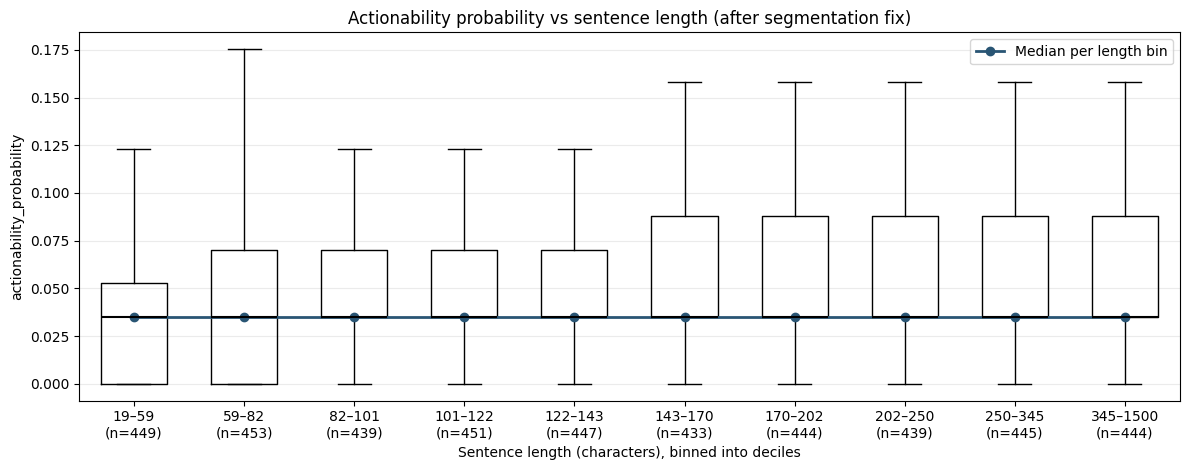

In [ ]:
# After-only plot: actionability_probability vs sentence length (binned)


prob_col = "actionability_probability"
text_col = "sentence"

for c in [prob_col, text_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

df_len = df_out[[prob_col, text_col]].copy()
df_len[prob_col] = pd.to_numeric(df_len[prob_col], errors="coerce")
df_len[text_col] = df_len[text_col].astype(str)
df_len["char_len"] = df_len[text_col].str.len()
df_len = df_len.dropna(subset=[prob_col])
df_len = df_len[df_len["char_len"] > 0].copy()

# Create length deciles (10 bins). duplicates='drop' handles tied lengths.
df_len["len_decile"] = pd.qcut(df_len["char_len"], q=10, duplicates="drop")

# Boxplot data in decile order
groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]

# Summary line: median probability per bin
medians = df_len.groupby("len_decile", sort=True)[prob_col].median().to_numpy()

# counts per bin (for labels)
bin_counts = df_len.groupby("len_decile", sort=True)[prob_col].size().to_numpy()

# Use a data-driven y-limit to make the plot readable (cap at 0.30)
y_hi = float(np.nanpercentile(df_len[prob_col].to_numpy(), 99))
y_hi = min(max(y_hi, 0.15), 0.30)  # keep in a sensible band for reports

fig, ax = plt.subplots(figsize=(12, 4.8))

ax.boxplot(
    groups,
    labels=[f"{lab}\n(n={n})" for lab, n in zip(labels, bin_counts)],
    showfliers=False,
    widths=0.6,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

ax.plot(
    np.arange(1, len(medians) + 1),
    medians,
    color="#295574",
    linewidth=2,
    marker="o",
    label="Median per length bin",
)

ax.set_title("Actionability probability vs sentence length ")
ax.set_xlabel("Sentence length (characters), binned into deciles")
ax.set_ylabel("actionability_probability")


ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### add_advice_flag
Testing function add_advice_flag 

In [188]:
# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

mask_pt = df_out[lang_col].astype(str).str.strip().str.lower().eq("pt")
mask_word = df_out[text_col].astype(str).str.contains(
    r"\b(recomenda|recomendado|recomendação|recomendar|recomendo|recomendava|recomendou|recomende)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits = df_out.loc[mask_pt & mask_word, [lang_col, score_col, text_col]].copy()
hits[score_col] = pd.to_numeric(hits[score_col], errors="coerce")
hits = hits.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits)} Portuguese sentences containing 'recomend*':\n")
for i, r in hits.iterrows():
    print(f"{i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

# save sentences to a list
portuguese_sentences = hits[text_col].astype(str).tolist()

Found 10 Portuguese sentences containing 'recomend*':

001 | p=0.7895 | CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul.
002 | p=0.7895 | Também não é recomendado estacionar veículos próximos a torres de transmissão e placas de propaganda.
003 | p=0.7895 | Em caso de rajadas de vento, o instituto recomenda que as pessoas não se abriguem debaixo de árvores e não estacionem veículos próximos a torres de transmissão e placas de propaganda.
004 | p=0.7368 | O Inmet recomenda que, em caso de rajadas de ventos, as pessoas não se abriguem deba

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_73999/3786657601.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_word = df_out[text_col].astype(str).str.contains(


In [189]:


# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# -------------------------
# EN: recommend/suggest/advise (print with score)
# -------------------------
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(
    r"\b(?:recommend|recommends|recommended|recommending|suggests|advises|urge|urges|urged|urging)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, score_col, text_col]].copy()
hits_en[score_col] = pd.to_numeric(hits_en[score_col], errors="coerce")
hits_en = hits_en.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_en)} English sentences containing recommend*/suggests/advises:\n")
for i, r in hits_en.iterrows():
    print(f"EN {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

print("\n" + "-" * 80 + "\n")

# -------------------------
# ES: recomend* (print with score)
# -------------------------
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(
    r"\brecomend",
    flags=re.IGNORECASE,
    regex=True,
)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, score_col, text_col]].copy()
hits_es[score_col] = pd.to_numeric(hits_es[score_col], errors="coerce")
hits_es = hits_es.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_es)} Spanish sentences containing 'recomend*':\n")
for i, r in hits_es.iterrows():
    print(f"ES {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

Found 5 English sentences containing recommend*/suggests/advises:

EN 001 | p=0.7719 | B.C. residents urged not to panic-buy as bare shelves fuel food security angstFlooding has put pressure on B.C.'s dairy, chicken, and egg industry; province says there's enough foodProvincial leaders are urging British Columbians not to hoard food and groceries as disruptions to B.C.'s farm industry and supply chains from historic rain and flooding fuels angst amid consumers.
EN 002 | p=0.7719 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 003 | p=0.7368 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 004 | p=0.7368 | Three other unit leaders who were not with the transport have also been recommended for reprimands.
EN 005 | p=0.7368 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.

-----------------------------

In [190]:

import re

text_col = "sentence"
lang_col = "language"

for c in [text_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# --- English: suggests OR advises ---
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(r"\b(?:suggests|advises)\b", flags=re.IGNORECASE, regex=True)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_en)} English sentences containing 'suggests' or 'advises':\n")
for i, s in enumerate(hits_en[text_col].astype(str).tolist(), start=1):
    print(f"EN {i:03d} | {s}")

print("\n" + "-" * 80 + "\n")

# --- Spanish: sugiere OR aconseja ---
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(r"\b(?:sugiere|aconseja)\b", flags=re.IGNORECASE, regex=True)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_es)} Spanish sentences containing 'sugiere' or 'aconseja':\n")
for i, s in enumerate(hits_es[text_col].astype(str).tolist(), start=1):
    print(f"ES {i:03d} | {s}")

Found 0 English sentences containing 'suggests' or 'advises':


--------------------------------------------------------------------------------

Found 2 Spanish sentences containing 'sugiere' or 'aconseja':

ES 001 | Según el informe, el volumen de desapariciones en la capital del país sugiere un 'deterioro en las capacidades de las fiscalías y un recrudecimiento del conflicto entre grupos criminales locales y nuevas organizaciones'.
ES 002 | Te has suscrito a notificacionesConfigura y elige tus preferenciasLas alcaldías donde se activó la alerta amarilla son: Álvaro Obregón, Benito Juárez, Coyoacán, Cuauhtémoc, Cuajimalpa, Iztacalco, Iztapalapa, Magdalena Contreras, Tlalpan y Venustiano CarranzaSe sugiere permanecer atento a las actualizaciones meteorológicas.


# Investigation Bias in actionability detection by language 
Distribution of actionability and potential bias in detection by language

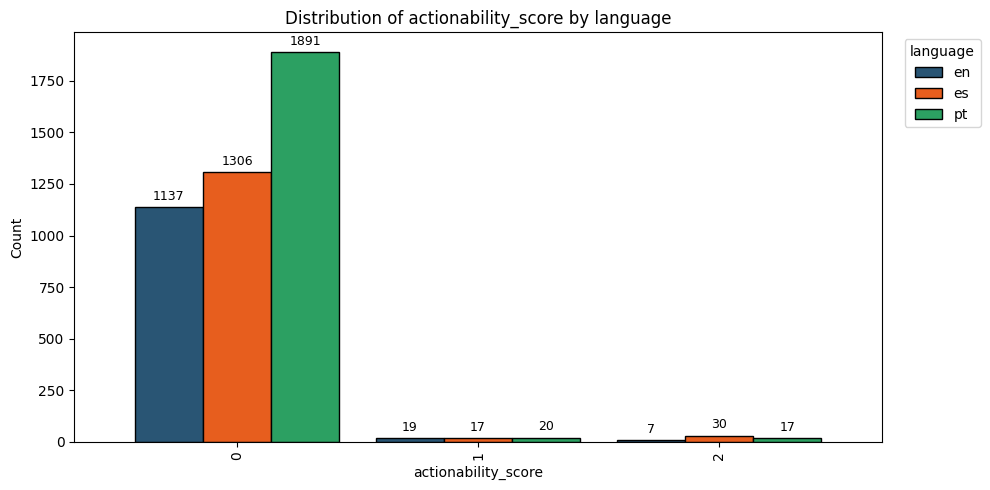

In [196]:

# Distribution of actionability_score (0/1/2) by language, with counts on bars

score_col = "actionability_score"
lang_col = "language"

for c in [score_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, lang_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[score_col, lang_col])

# Keep only scores 0/1/2
dfp = dfp[dfp[score_col].isin([0, 1, 2])].copy()
dfp[score_col] = dfp[score_col].astype(int)

# counts per score per language (rows=score, cols=language)
ct = (
    dfp.groupby([score_col, lang_col])
       .size()
       .unstack(lang_col)
       .fillna(0)
       .astype(int)
 )

# Ensure rows are ordered 0,1,2 even if missing
ct = ct.reindex([0, 1, 2], fill_value=0)

# Stable column order + colors driven by the first cell
ordered_langs = [l for l in LANG_ORDER if l in ct.columns] + [l for l in ct.columns if l not in LANG_ORDER]
ct = ct[ordered_langs]
colors = [lang_color(l) for l in ct.columns]

ax = ct.plot(kind="bar", figsize=(10, 5), width=0.85, edgecolor="black", color=colors)

ax.set_title("Distribution of actionability_score by language")
ax.set_xlabel("actionability_score")
ax.set_ylabel("Count")
ax.legend(title="language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues], padding=3, fontsize=9)

plt.show()

In [192]:
#read final cv
df_final = pd.read_csv("../output/enriched.csv")
df_final[["actionability_percentage","country","scope","dominant_frame"]].head(30)

,actionability_percentage,country,scope,dominant_frame
0,0.00,Argentina,local,impact
1,0.00,Argentina,local,accountability
2,0.00,Bolivia (Plurinational State of),local,impact
3,0.00,Bolivia (Plurinational State of),local,response
4,0.00,Bolivia (Plurinational State of),local,response
5,0.00,Brazil,national,response
6,0.00,Brazil,local,accountability
7,0.00,Brazil,local,impact
8,12.50,Brazil,local,response
9,0.00,Brazil,local,impact


### Investigation false negatives 
(still have not done this part)

In [193]:
df_out[["sentence", "actionability_probability"]].nsmallest(
    20, "actionability_probability"
)

,sentence,actionability_probability
1,Comienza a revertirse el déficit pluviométrico que dejó el invierno en esta región.,0.0
3,"Su desplazamiento favoreció el desarrollo de tormentas aisladas severas en la región pampeana, produciendo luego un moderado descenso de temperaturas.",0.0
6,"En la región central relativas altas presiones estarán presentes al menos hasta el miércoles, prevaleciendo el buen tiempo a pesar de la nubosidad pasajera.",0.0
9,"En tal sentido, el Servicio Meteorológico Nacio",0.0
15,"Registros pluviométricos extraoficiales, indican precipitaciones de hasta 130mm en la provincia.",0.0
45,"No Rio de Janeiro, foi decretado situação de emergência na semana passada depois q",0.0
52,"No dia 15 de maio de 2018, o pr",0.0
58,Também acabou tombando outro poste na Rua América.,0.0
59,"O aposentado contou que a chuva não foi volumosa, mas os ventos eram fortes suficientes para provocar estragos, como ocorreu.",0.0
61,"Durou no máximo dez minutos e fez todo esse estrago', relatou.",0.0


## Audit by article 

### Investigating Stability in results and relevance of overall actionability per article 

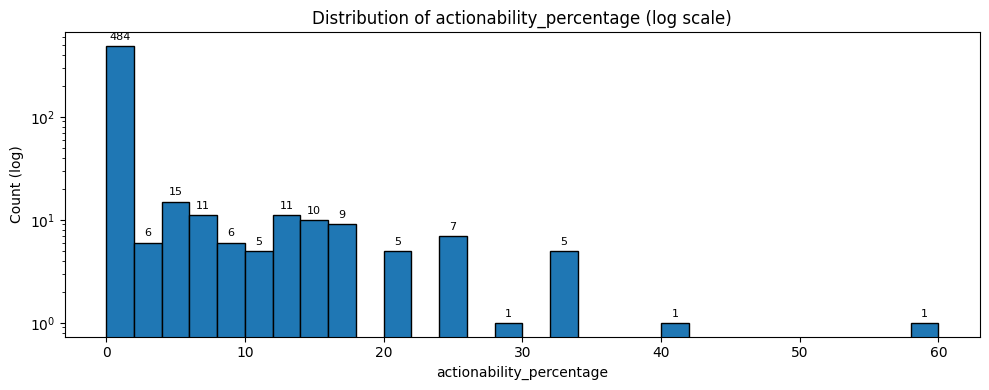

In [194]:
#distrubuiton of actionability percentage 
col = "actionability_percentage"

if col not in df_final.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_final.columns)}")

s = pd.to_numeric(df_final[col], errors="coerce").dropna()

# If it's 0-1, convert to 0-100 for nicer bins (auto-detect)
if (s.max() <= 1.0) and (s.min() >= 0.0):
    s_plot = s * 100.0
    x_label = "actionability_percentage (%)"
else:
    s_plot = s
    x_label = col

bins = 30  # adjust if needed

fig, ax = plt.subplots(figsize=(10, 4))

counts, bin_edges, patches = ax.hist(s_plot, bins=bins, edgecolor="black")

ax.set_yscale("log")
ax.set_title(f"Distribution of {col} (log scale)")
ax.set_xlabel(x_label)
ax.set_ylabel("Count (log)")

# print counts on top of bars (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


,lang_a,lang_b,n_a,n_b,ks_stat,ks_p,wasserstein,js_distance,ws_CI95,js_CI95
0,en,es,1163,1353,0.021,0.933,0.0108,0.0994,"[0.0064, 0.0181]","[0.1021, 0.1421]"
1,en,pt,1163,1928,0.110,4.41e-08,0.0146,0.1399,"[0.0109, 0.0203]","[0.1316, 0.1776]"
2,es,pt,1353,1928,0.101,1.42e-07,0.0221,0.1289,"[0.0146, 0.0304]","[0.1230, 0.1617]"


KS test (alpha=0.05): reject equality for 2/3 pairs.
Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.
Max Wasserstein distance across pairs: 0.0221 (units: probability).
Max Jensen–Shannon distance across pairs: 0.1399.
